# Детекция ботов на Авито

Я придерживаюсь следующего плана в этом ноутбуке:

1. Разобраться, как устроены боты на Авито и какие следы они оставляют в таких данных.
2. Посмотреть на данные, проверить пропуски, структуру окна, платформы, курсор.
3. Построить признаки на основе пункта 1.
4. Сформулировать гипотезы и проверить их.
5. Обучить модели, сравнить, улучшить и зафиксировать финальное решение.

Весь тяжёлый код вынесен в features.py, hypotheses.py, compare_models.py, propagate.py, stack.py, seq_model.py и gnn_model.py, здесь я вызываю их и разбираю результаты.

## 0. Воспроизводимость

В решении есть случайность. Это перемешивание фолдов, подвыборки и сиды бустингов, бутстрэп в проверке гипотез и инициализация нейросетей. Все модули берут seed из одного места, из переменной окружения BOT_SEED

In [1]:
import os
SEED = 11
os.environ["BOT_SEED"] = str(SEED)
import seed
seed.set_global_seed(SEED)
print("seed зафиксирован:", seed.SEED)

seed зафиксирован: 11


## 1. Как устроены боты на Авито

Я посмотрел исходный код опенсорс решений для парсинга на Авито, а также как работают коммерческие скраперы (только по документации) и инструменты обхода блокировки ботов. Ниже опишу те семейства, которые будут полезны для решения задачи, то есть следы которых видно в наших полях. В задаче сказано, что нужно детектить именно сборщиков данных, поэтому я не рассматривал например накрутчиков просмотров.

**1. HTTP-парсеры без браузера.** В основном используются requests, aiohttp, Scrapy, curl, Go. Особенность их в том, что JavaScript не исполняется, поэтому в браузерную аналитику такие клиенты либо не попадают, либо попадают с "голым" User-Agent HTTP-библиотеки. Они оставляют такой след - User-Agent вида "python-requests", "Scrapy", "Go-http-client", "node-fetch", также нет ни одного события с координатами курсора.
Из популярных найденных мной это [blohinn/telegram-avito-bot](https://github.com/blohinn/telegram-avito-bot) (requests + BS4), [useless-apple/avito_parser](https://github.com/useless-apple/avito_parser), [pleaz/avito](https://github.com/pleaz/avito) (Scrapy), [songd/avito-search-scraper](https://apify.com/songd/avito-search-scraper) (у этого написано прям "does not run a headless browser").

**2. Headless-браузеры: Playwright, Puppeteer, Selenium.** Исполняют JS, поэтому оставляют полноценные события, но кликают телепортом, используется "locator.click()" одно перемещение мыши в центр элемента и сразу клик, без траектории. У решения nodriver "Element.click() это вообще JS-клик без событий с координатами курсора. Ещё у них окно фиксировано, например 1280×720 по умолчанию у Playwright, 1920×1080 в mcp-avito, 1200×600 и 1280×800 в других парсерах. User-Agent берётся из пресета и устаревает, например mcp-avito ставит Chrome 119/120. Эту категорию можно задетектить через прыжки между соседними позициями курсора, они либо нулевые, либо огромные, также через малый разброс координат, максимумы координат на стандартных размерах окна и "HeadlessChrome" в User-Agent.
Всю информацию взял отсюда: [документация Playwright `mouse.move`/`click`](https://playwright.dev/docs/api/class-mouse), [nodriver](https://github.com/ultrafunkamsterdam/nodriver) (`element.py`: `el.click()`), [patchright](https://github.com/Kaliiiiiiiiii-Vinyzu/patchright), [Ascard/mcp-avito](https://github.com/Ascard/mcp-avito), [maxRakh/python_avito_parser](https://github.com/maxRakh/python_avito_parser), [xailiry/avito-parser-sdk](https://github.com/xailiry/avito-parser-sdk).

**3. Мониторы новых объявлений.** Используют один поисковый URL, обычно первая страница, опрос по расписанию, к примеру раз в 2 минуты у blohinn, от 60 секунд у DeckhandThunder, до раза в секунду у Avtoringer. Между запросами фиксированное время сна. Распознать их можно через короткие и однородные интервалы между событиями, либо один и тот же запрос много раз, почти все его события это search_results_view, фото он не листает.
Ссылки на источники: [blohinn](https://github.com/blohinn/telegram-avito-bot) (тут прям в коде "schedule.every(2).minutes"), [DeckhandThunder/avito-parser-monitor](https://github.com/DeckhandThunder/avito-parser-monitor), [Avtoringer](https://avtoringer.ru/) (здесь указаны тарифы по интервалу опроса), [NKaty/Avito-scraper](https://github.com/NKaty/Avito-scraper) (в коде есть "ratelimit(3000)").

**4. Краулеры категорий.** Проходятся циклом по страницам выдачи, обход по городам и категориям, используют дробление по цене ради обхода лимита в 100 страниц. Распознать можно по глубокой пагинации, много локаций и категорий на одну куку, много различных объявлений, мало повторных просмотров.
Источники: [Duff89/parser_avito](https://github.com/Duff89/parser_avito) (здесь в коде "for page in range(1, count+1)"), [vadimcoder/avito-crawl](https://github.com/vadimcoder/avito-crawl) (лимит 100 страниц, 6 диапазонов цены), [DimaKalbfleysh/Avito](https://github.com/DimaKalbfleysh/Avito) (категории, города и метро), [codefather-labs/avito-parser](https://github.com/codefather-labs/avito-parser).

**5. Пресеты User-Agent и общие объявления.** Один скрипт запускает много кук с одной строкой User-Agent (у Duff89 User-Agent константа, у mcp-avito случайный из пяти). Куки одного краулера или одной сети обходят одни и те же объявления в одно время. Распознать можно используя тот факт, что строку User-Agent делят подозрительно много кук, а также через куки-соседи по общим объявлениям.
Ссылки на источники: [Duff89](https://github.com/Duff89/parser_avito) (код содержит "common_data.HEADERS"), [Ascard/mcp-avito](https://github.com/Ascard/mcp-avito).

**6. Свежие профили.** Headless-браузер и nodriver стартуют с новым временным профилем, значит кука создаётся в момент первого запроса. Duff89 покупает cookies, которые живут до 12 часов. Распознаётся на основе того что кука создана внутри окна наблюдения или незадолго до него.
Ссылки на источники: [nodriver](https://github.com/ultrafunkamsterdam/nodriver), [Duff89, docs/ANTIBLOCK.md](https://github.com/Duff89/parser_avito).

## 2. Данные и разведочный анализ

In [2]:
import sys, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)

In [3]:
ev = pd.read_csv("data/events.csv.gz")
train = pd.read_csv("data/train.csv"); test = pd.read_csv("data/test.csv")
print(f"событий: {len(ev):,}, кук train: {len(train):,} (ботов {train.target.mean():.1%}), кук test: {len(test):,}")
ev.head(3)

событий: 328,905, кук train: 11,091 (ботов 8.1%), кук test: 4,909


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0


Посмотрим какие есть типы событий и платформы. Здесь desktop и web это один и тот же веб

In [4]:
ev["platform_norm"] = ev.platform.str.lower().replace({"desktop": "web", "iphone": "ios"})
lab = ev.merge(train[["cookie_id", "target"]], on="cookie_id")
print(pd.crosstab(lab.event_name, lab.platform_norm))

platform_norm         android   ios    web
event_name                                
captcha_shown            2540   250   5138
contact_chat_open        2013   249   2095
contact_message_sent     1003   124   1110
contact_phone_show       3626   450   3998
favorite_add             5681   763   7346
item_view               32919  4420  49730
login                    1820   242   2444
photo_swipe             10866  1435  14083
search_results_view     27195  3652  41474
seller_page_view         4947   617   6985


Посмотрим на пропуски

In [5]:
nulls = ev.assign(has_pointer=ev.pointer_x.notna()).groupby("platform_norm").agg(
    pointer_share=("has_pointer", "mean"), item_null=("item_id", lambda s: s.isna().mean()),
    query_null=("search_query", lambda s: s.isna().mean())).round(3)
print(nulls)
print("\nдоля web-событий с курсором по классу User-Agent:")
ua_class = np.select([ev.user_agent.str.contains("Headless"), ev.user_agent.str.startswith("Avito/"),
                      ev.user_agent.str.startswith("Mozilla")], ["headless", "app", "browser"], "http_lib")
web = ev.assign(pv=ev.pointer_x.notna(), ua=ua_class).query("platform_norm == 'web'")
print(web.groupby("ua").pv.mean().round(3))

               pointer_share  item_null  query_null
platform_norm                                      
android                0.000      0.336       0.704
ios                    0.000      0.339       0.698
web                    0.585      0.358       0.688

доля web-событий с курсором по классу User-Agent:


ua
browser     0.602
headless    0.407
http_lib    0.493
Name: pv, dtype: float64


Видно что item_id и seller_type пусты у выдачи, а search_query и search_page пусты у всего, кроме выдачи, и курсор есть только на вебе. То есть пропуски структурные, а не случайные.

Значит заполнять пропуски нельзя, потому что отсутствие курсора у веб-куки само по себе след HTTP-парсера или JS-клика, а на мобильных платформах курсора не бывает вовсе.

Теперь User-Agent

In [6]:
print("различных User-Agent:", ev.user_agent.nunique())
print(lab.assign(ua=np.select([lab.user_agent.str.contains("Headless"), lab.user_agent.str.startswith("Avito/"),
      lab.user_agent.str.startswith("Mozilla")], ["headless", "app", "browser"], "http_lib"))
      .groupby("ua").agg(events=("target", "size"), bot_share_of_events=("target", "mean")).round(3))
print("\nпримеры HTTP-библиотек:", sorted(ev.loc[ua_class == "http_lib", "user_agent"].unique()))

различных User-Agent: 148


          events  bot_share_of_events
ua                                   
app        45050                0.196
browser   179780                0.164
headless    9015                0.569
http_lib    5370                0.485



примеры HTTP-библиотек: ['Go-http-client/1.1', 'Scrapy/2.11.0 (+https://scrapy.org)', 'curl/8.1.2', 'node-fetch/3.3.2', 'python-requests/2.31.0', 'python-urllib3/2.0.7']


Всего 148 различных строк, среди них уже описанные выше HTTP-библиотеки и HeadlessChrome.

Посмотрим на события, которые происходят после окна. В частности интересует показ капчи.

доля событий после окна:
sample
test     0.00
train    0.17
Name: after_window, dtype: float64
капч всего: 7928, из них после окна: 7928


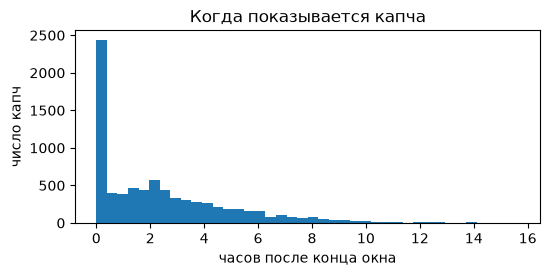

In [7]:
# Помечаю каждое событие, а именно из train или test кука, и попадает ли событие в окно наблюдения
meta = pd.concat([train.assign(sample="train"), test.assign(sample="test")])
events = ev.merge(meta, on="cookie_id")
events["ts"] = pd.to_datetime(events.event_ts)
events["window_end"] = pd.to_datetime(events.window_end_ts)
events["after_window"] = events.ts >= events.window_end

print("доля событий после окна:")
print(events.groupby("sample").after_window.mean().round(3))

captcha = events[events.event_name == "captcha_shown"]
print(f"капч всего: {len(captcha)}, из них после окна: {captcha.after_window.sum()}")

hours_after_end = (captcha.ts - captcha.window_end).dt.total_seconds() / 3600
plt.figure(figsize=(6, 2.5))
plt.hist(hours_after_end, bins=40)
plt.xlabel("часов после конца окна"); plt.ylabel("число капч"); plt.title("Когда показывается капча")
plt.show()

Важное наблюдение, что окно наблюдения это один день, но в трейне часть событий лежит после окна, а в тесте таких событий нет вообще. И все показы капчи происходят именно там

Значит события после окна относится именно к train, и любой признак на них поднимет кросс-валидацию и ничего не даст на test. Поэтому я отброшу всё за пределами окна, а капчу не буду использовать вовсе, хотя среди кук с капчей 77 % ботов.

Посмотрю сколько событий, в какие часы, какие интервалы между событиями

        n_events  median_gap  serp_share  max_page  pointer_share
target                                                           
0.0         12.0        59.0        0.30       4.0           0.93
1.0         20.0        25.0        0.33       7.0           0.00


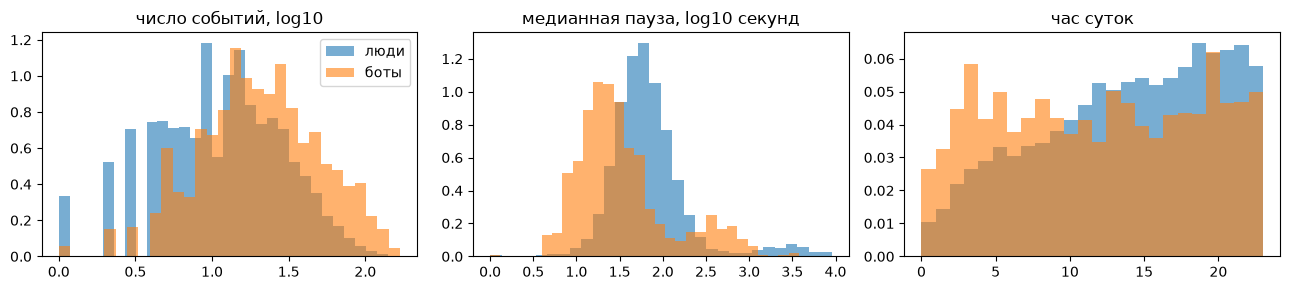

In [8]:
# Беру только события train внутри окна и считаю по каждой куке пять простых характеристик
inside = events[(events["sample"] == "train") & ~events.after_window].sort_values(["cookie_id", "ts"])
inside["gap_sec"] = inside.groupby("cookie_id").ts.diff().dt.total_seconds()      # пауза до предыдущего события
inside["has_pointer"] = np.where(inside.platform_norm == "web", inside.pointer_x.notna(), np.nan)  # только веб

per_cookie = inside.groupby("cookie_id").agg(
    target=("target", "first"),
    n_events=("ts", "size"),
    median_gap=("gap_sec", "median"),
    serp_share=("event_name", lambda s: (s == "search_results_view").mean()),
    max_page=("search_page", "max"),
    pointer_share=("has_pointer", "mean"),
)
print(per_cookie.groupby("target")[["n_events", "median_gap", "serp_share", "max_page", "pointer_share"]].median().round(2))

# Три распределения (боты и люди)
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
for target, name in ((0, "люди"), (1, "боты")):
    p = per_cookie[per_cookie.target == target]
    ax[0].hist(np.log10(p.n_events), bins=30, alpha=.6, density=True, label=name)
    ax[1].hist(np.log10(p.median_gap.dropna() + 1), bins=30, alpha=.6, density=True, label=name)
    ax[2].hist(inside.loc[inside.target == target, "ts"].dt.hour, bins=24, alpha=.6, density=True, label=name)
ax[0].set_title("число событий, log10"); ax[1].set_title("медианная пауза, log10 секунд"); ax[2].set_title("час суток")
ax[0].legend(); plt.tight_layout(); plt.show()

Здесь уже видны следы мониторов и краулеров, которые описывал выше

У ботов больше событий, вдвое короче интервалы, глубже пагинация, а на вебе у медианного бота курсора нет вовсе, тогда как у медианного человека он есть почти на всех событиях

Однородны ли боты? Попробую кластеризовать их по пяти статистикам, а именно по числу событий, медианной паузе между событиями в секундах, доле просмотров выдачи, максимальному номеру страницы выдачи и по доле веб-событий с курсором

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X = per_cookie[per_cookie.target == 1][["n_events", "median_gap", "serp_share", "max_page", "pointer_share"]].fillna(0)
X = StandardScaler().fit_transform(np.log1p(X))
for k in (2, 3, 4):
    lbl = KMeans(k, n_init=10, random_state=SEED).fit_predict(X)
    print(f"k={k}: силуэт {silhouette_score(X, lbl):.2f}, размеры {np.bincount(lbl).tolist()}")

k=2: силуэт 0.27, размеры [448, 451]
k=3: силуэт 0.31, размеры [316, 349, 234]
k=4: силуэт 0.33, размеры [151, 337, 212, 199]


Силуэт (то насколько точка ближе к своей группе, чем к соседней) около 0,2-0,3, то есть боты не распадаются на чёткие группы, семейства перекрываются. Значит линейная модель будет проигрывать деревьям, а признаки надо строить так, чтобы каждое семейство ловилось своим набором

Выбросы я не чищу, так как именно выбросы здесь помогают определять ботов. Единственное что надо сделать это убрать дубликаты одного и того же события в течение 5 секунд (ретраи скриптов после ошибки), их я считаю отдельным признаком

## 3. Признаки

На основе следов, которые оставляют найденные в первом пункте методы, я делаю признаки. Я считаю их по куке внутри её окна, это делает скрипт features.py.

Первая таблица содержит признаки, которые явно привязаны к следу конкретного семейства.

| Семейство | След | Признаки |
|---|---|---|
| HTTP-парсеры | User-Agent библиотеки, JS не исполняется, курсора нет | `ua_nonbrowser`, `pointer_missing_share_web` |
| Headless-браузеры | клик телепортом, нет траектории между соседними позициями | `jump_dist_median` и `udist_jump_dist_median`, `jump_zero_share`, `jump_gt_500_share`, `pointer_std_x`, `pointer_bbox_area_log` |
| Headless-браузеры | клик в центр элемента | `coord_round10_share`, `pointer_by_class_eta2_x` |
| Headless-браузеры | фиксированный размер окна | `max_x`, `viewport_default_flag` |
| Headless-браузеры | пресет User-Agent, HeadlessChrome или устаревшая версия | `ua_headless`, `browser_lag` |
| Мониторы | `sleep` с фиксированной или узкой задержкой | `iei_median`, `iei_cv`, `iei_iqr_over_median`, `iei_log_std`, `iei_mode_share`, `iei_share_2_15s` |
| Мониторы | один и тот же запрос, первая страница | `max_query_repeats`, `page1_only_repeats` |
| Мониторы и краулеры | скрипт читает выдачу, а фото и продавец ему не нужны | `serp_share`, `photo_share`, `seller_per_item`, `items_per_serp` |
| Краулеры | цикл по страницам | `max_search_page`, `page_ge_10_any`, `page_step_eq_1_share` |
| Краулеры | обход по городам и категориям | `n_locations`, `n_categories`, `cat_loc_grid_ratio`, `n_items` |
| Общая инфраструктура | один скрипт, много кук с одним User-Agent | `ua_cookie_count`, `ua_hash_bot_rate_oof` |
| Общая инфраструктура | куки одного краулера обходят одни объявления | `items_shared_cookies_mean`, `neighbor_bot_rate_oof` |
| Свежие профили | кука создаётся первым запросом скрипта | `cookie_age_h`, `created_in_window`, `first_event_minus_created_s` |

Признаки без привязки к одному семейству:

| Признак | Зачем |
|---|---|
| `share_platform_web`, `share_platform_android`, `share_platform_ios`, `n_web_events`, `few_events` | контекст платформы. Пропуск в курсорных признаках у мобильной куки и у HTTP-парсера выглядит одинаково, модель должна их различать |
| `max_events_per_min`, `items_per_min`, `iei_min`, `share_iei_eq_0` | скорость, недостижимая для человека, параллельные запросы любого скрипта |
| `long_pause_share`, `max_gap_ratio` | скрипт не отвлекается, у человека есть паузы в десятки минут |
| `event_type_entropy`, `bigram_serp_serp`, `bigram_item_item` | однотипный цикл. Скрипт повторяет одно действие, человек переключается |
| `udist_n_events`, `udist_n_distinct_queries` | боты на обоих краях. Мониторы дают мало событий и один запрос, краулеры много. Расстояние от медианы людей делает признак монотонным |
| `fav_per_item` | избранное является действием человека, у парсеров его нет. Заодно отделяет накрутку, которая не наш класс |

Если признаки с метками (доли ботов среди кук с тем же User-Agent и среди соседей по объявлениям) считать по всем меткам, то кука увидит собственную метку через соседей и модель научится читать ответ. Поэтому для куки недели 1 долю будем считать только по меткам недели 0 и наоборот, то есть out-of-fold по неделям, а при обучении моделей пересчитывать заново в каждом сплите

In [10]:
%%capture
!{sys.executable} features.py --data data --out out

In [11]:
import json
feats = pd.read_csv("out/features.csv")
groups = json.load(open("out/feature_groups.json", encoding="utf-8"))
print({k: len(v) for k, v in groups.items()})
feats[["cookie_id", "n_events", "iei_median", "iei_cv", "max_search_page", "pointer_missing_share_web",
       "jump_dist_median", "max_x", "items_shared_cookies_mean", "cookie_age_h"]].head()

{'ритм': 23, 'кука и окно': 8, 'состав событий': 45, 'разнообразие': 11, 'курсор': 18, 'user-agent и платформа': 18, 'с метками и udist': 10}


,cookie_id,n_events,iei_median,iei_cv,max_search_page,pointer_missing_share_web,jump_dist_median,max_x,items_shared_cookies_mean,cookie_age_h
0,ck_54a059eb7d3ea68b,7,21.0,0.982273,6.0,NaN,NaN,NaN,2.000000,3254.488611
1,ck_7e4de46eeab82974,41,57.5,2.417562,8.0,0.073171,659.794665,1907.0,2.315789,4669.826667
2,ck_9320229ef6304522,36,22.0,2.180377,10.0,0.027778,846.480709,1904.0,3.368421,791.866111
3,ck_30ccd25bc1714ed9,21,54.5,2.832272,2.0,1.000000,NaN,NaN,2.000000,13.122222
4,ck_a77c5f05948cdeef,29,51.5,2.477664,7.0,0.034483,597.850316,1791.0,3.750000,2276.090278


Признаки выглядят разумно, потому что видны пропуски там, где веб-кук нет, также возраст куки записан в часах, а глубина страницы целая

## 4. Гипотезы

Я поставил гипотезы на основе наших данных и тех знаний о методах создания ботов для Авито, полученных в первом пункте. Тесты односторонние. Дискретный признак проверяется точным критерием Фишера, непрерывный Манна-Уитни с AUC как размером эффекта, форма распределения проверяется двухвыборочным Колмогоровым-Смирновым

| № | Гипотеза | Откуда | Признак |
|---|---|---|---|
| H1 | Куки с User-Agent HTTP-библиотеки почти всегда боты | семейство 1 | `ua_nonbrowser` |
| H2 | У ботов на вебе чаще нет координат курсора | семейства 1, 2 | `pointer_missing_share_web` |
| H3 | Прыжки курсора между соседними событиями у ботов либо нулевые, либо огромные | семейство 2, телепорт-клики | `udist_jump_dist_median` |
| H4 | Разброс курсора у ботов меньше | семейство 2 | `pointer_std_x` |
| H5 | Максимумы координат у ботов сидят на стандартных размерах окна | семейство 2, фиксированный viewport | `max_x` |
| H6 | Медианный интервал между событиями у ботов меньше | семейство 3, sleep | `iei_median` |
| H7 | Интервалы у ботов однороднее | семейство 3 | `iei_iqr_over_median` |
| H8 | Один запрос у ботов повторяется чаще | семейство 3 | `max_query_repeats` |
| H9 | Доля выдачи выше, доля фото ниже | семейства 3, 4 | `serp_share`, `photo_share` |
| H10 | Глубина пагинации у ботов больше | семейство 4 | `max_search_page` |
| H11 | Локаций на куку у ботов больше | семейство 4 | `n_locations` |
| H12 | Боты делят объявления с другими куками сильнее | семейство 5 | `items_shared_cookies_mean`, `neighbor_bot_rate_oof` |
| H13 | Куки ботов моложе | семейство 6 | `cookie_age_h` |
| H14 | Интервалы у ботов кратны «круглым» периодам опроса | семейство 3, буквальное прочтение schedule.every(2).minutes | `iei_round_share` |
| H15 | В одной куке у ботов несколько User-Agent | ротация User-Agent в парсерах | `n_distinct_ua` |
| H16 | Автокорреляция интервалов у ботов выше | периодический опрос | `iei_acf1` |

## 5. Проверка гипотез

Протокол в две стадии, потому что test начинается позже train и потому что после отбора лучших признаков их эффект на тех же данных завышен:

1. Скрининг на первой неделе train, поправка Бенджамини-Хохберга при q = 0,01.
2. Подтверждение на второй неделе только для прошедших, $\alpha$ = 0,01.

При 11 тысячах кук критерий отвергает нулевую гипотезу уже при AUC 0,52, а такая разница модели бесполезна. Поэтому кроме значимости я требую размер эффекта. Для непрерывного признака я требую AUC не ниже 0,55 в ожидаемую сторону, и бутстрэп-интервал AUC не накрывает 0,5, чтобы эффект не оказался случайным. Для флага я требую не меньше 30 кук с флагом, иначе precision на них не оценить, и precision не ниже 0,25, то есть втрое выше базовой доли ботов 8%, чтобы флаг реально обогащал выборку

In [12]:
%%capture
!{sys.executable} hypotheses.py --features out/features.csv --out out

In [13]:
res = pd.read_csv("out/hypothesis_results.csv")
mine = {"ua_nonbrowser": "H1", "pointer_missing_share_web": "H2", "udist_jump_dist_median": "H3", "pointer_std_x": "H4",
        "max_x": "H5", "iei_median": "H6", "iei_iqr_over_median": "H7", "max_query_repeats": "H8", "serp_share": "H9",
        "photo_share": "H9", "max_search_page": "H10", "n_locations": "H11", "items_shared_cookies_mean": "H12",
        "neighbor_bot_rate_oof": "H12", "cookie_age_h": "H13", "iei_round_share": "H14", "n_distinct_ua": "H15", "iei_acf1": "H16"}
r = res[res.feature.isin(mine)].drop_duplicates("feature").assign(H=lambda d: d.feature.map(mine))
r["эффект_1"] = r.s1_effect.round(3); r["эффект_2"] = r.s2_effect.round(3)
r["итог"] = np.select([r.confirmed, r.s1_pass], ["подтверждена", "не подтвердилась на 2-й неделе"], "не подтверждена")
print(r.sort_values("H", key=lambda s: s.str[1:].astype(int))[["H", "feature", "kind", "direction", "эффект_1", "s1_p_adj", "эффект_2", "итог"]].to_string(index=False))

  H                   feature kind direction  эффект_1      s1_p_adj  эффект_2                           итог
 H1             ua_nonbrowser flag    higher     0.276  7.771855e-09     0.158 не подтвердилась на 2-й неделе
 H2 pointer_missing_share_web cont    higher     0.648  6.456954e-19     0.663                   подтверждена
 H3    udist_jump_dist_median cont    higher     0.856  2.727788e-43     0.836                   подтверждена
 H4             pointer_std_x cont     lower     0.095  5.642036e-56     0.105                   подтверждена
 H5                     max_x   ks       two     0.737  1.696119e-69     0.705                   подтверждена
 H6                iei_median cont     lower     0.277  2.177601e-58     0.262                   подтверждена
 H7       iei_iqr_over_median cont     lower     0.277  3.184764e-58     0.275                   подтверждена
 H8         max_query_repeats cont    higher     0.628  2.098610e-29     0.627                   подтверждена
 H9       

В таблице выше для непрерывных признаков эффект это AUC (для направления "ниже у ботов" хороший AUC меньше 0,5), для флагов это precision класса "бот" среди кук с флагом и для KS это расстояние между распределениями

## 6. Выводы по гипотезам

- Самый сильный след даёт курсор. Прыжки между соседними позициями (H3) и разброс координат (H4) дают AUC около 0,9 и 0,1 и устойчивы между неделями.
- У ботов интервалы вдвое короче и однороднее, страницы выдачи глубже, локаций больше.
- Подтверждается, что есть граф общих объявлений (H12).
- User-Agent HTTP-библиотеки (H1) значим, но precision ниже порога 0,25 на второй неделе. То есть в этих данных такие User-Agent есть и у людей, вероятно у размеченных вручную пограничных случаев. Как единственный признак он не годится, но как один из многих работает.
- Контрольные гипотезы не подтвердились, и это полезно. Круглых периодов нет (H14), потому что скрипты добавляют случайную задержку, смена UA внутри куки (H15) у ботов не чаще, автокорреляция интервалов (H16) у ботов даже ниже, потому что человек ходит сессиями, а скрипт со случайным временем сна даёт белый шум.

## 7. Модели

Я обучаю на подтверждённых признаках плюс на контексте платформы, всего получается 44 колонки. Две схемы валидации:

- Хронологическая, где обучение на первой неделе train, а оценка на второй
- 5-fold валидация на всём train для оценки разброса

Аналогично тому как считались признаки ранее, в обеих схемах признаки с метками пересчитываются только по обучающей части сплита, чтобы кросс-валидация не показывала завышенный результат

In [14]:
%%capture
!{sys.executable} compare_models.py --out out

In [15]:
cmp = pd.read_csv("out/model_comparison.csv")
cmp[~cmp.model.str.startswith("blend")][["model", "chrono_p_at_r70", "cv_oof_p_at_r70", "cv_folds_std", "cv_oof_pr_auc", "seconds"]]

,model,chrono_p_at_r70,cv_oof_p_at_r70,cv_folds_std,cv_oof_pr_auc,seconds
0,logreg,0.7950,0.7935,0.0350,0.7689,1.0964
1,random_forest,0.8720,0.8702,0.0208,0.7930,24.6250
2,lightgbm,0.8614,0.8702,0.0329,0.8142,6.1956
3,xgboost,0.8512,0.8634,0.0306,0.8132,7.4400
4,catboost,0.8773,0.8766,0.0224,0.8202,55.4637


Логистическая регрессия отстаёт на 0,06-0,08. Такая ситуация была предсказуема, потому что ранее (в разделе 2) кластеризация показала, что границы между классами нелинейны и зависят от платформы, а пропуски несут смысл, который линейная модель с заполнением пропуска и флагом о его наличии теряет. Ещё видно, что модели на основе деревьев различаются в пределах разброса по фолдам, CatBoost чуть впереди за счёт более сильной регуляризации, а LightGBM в восемь раз быстрее. Дальше в качестве базовой модели я беру LightGBM.

## 8. Улучшения

### 8.1. Усреднение моделей

Ранги предсказаний разных моделей (только тех, которые на основе деревьев) усредняются. Я так делаю исходя из того, что случайный лес ошибается иначе, чем бустинги, и добавляет больше всего.

In [16]:
cmp[cmp.model.str.startswith("blend")][["model", "chrono_p_at_r70", "cv_oof_p_at_r70"]]

,model,chrono_p_at_r70,cv_oof_p_at_r70
5,blend:lgb+cat+xgb,0.8827,0.8750
6,blend:lgb+cat+xgb+rf,0.8966,0.8714
7,blend:lgb+rf,0.8913,0.8741
8,blend:cat+rf,0.8882,0.8813


### 8.2. Распространение по графу общих объявлений

След куки-соседей по объявлениям в базовой модели представлен только долей ботов среди соседей. Но можно применить графовый подход здесь, в котором оценка неразмеченной куки смешивается с взвешенным средним оценок соседей, у размеченных кук закреплены метки, test-куки участвуют как неразмеченные узлы. Коэффициент смешивания лямбда выбирается по хронологическому сплиту.

In [17]:
%%capture
!{sys.executable} propagate.py --out out

In [18]:
pr = pd.read_csv("out/propagation_results.csv")
pr[pr.iters.isin([1, 3]) & pr["lambda"].isin([0, 0.1, 0.2, 0.3, 0.6])]

,lambda,iters,chrono_p_at_r70,cv_folds_mean,cv_folds_std
0,0.0,1,0.8614,0.8647,0.0319
1,0.1,1,0.8640,0.8651,0.0297
2,0.1,3,0.8619,0.8651,0.0297
5,0.2,1,0.8697,0.8615,0.0310
6,0.2,3,0.8701,0.8619,0.0337
9,0.3,1,0.8750,0.8696,0.0246
10,0.3,3,0.8800,0.8702,0.0250
13,0.6,1,0.7241,0.7197,0.0685
14,0.6,3,0.7901,0.7453,0.0532


При $\lambda$ = 0,3 прирост около 0,02 на хронологии и 0,005 на кросс-валидации, при $\lambda$ = 0,1 прироста почти нет, а при $\lambda$ от 0,4 ранжирование разваливается, потому что соседи с метками 0 и 1 перевешивают собственное поведение куки. В общем, буду использовать пропагацию как поправку

### 8.3. Стек второго уровня

Вместо фиксированной $\lambda$ пусть модель второго уровня сама решает, когда доверять графу. Га вход модели будут подаваться базовый score, четыре варианта пропагации, взвешенные средние по соседям и структура соседства. Для обучающей части базовые score получаются во вложенных фолдах, и для каждого вложенного фолда все зависимые от меток признаки пересчитываются без его меток, иначе второй уровень увидел бы свои же ответы.

In [19]:
!{sys.executable} stack.py --out out --write

неделя 0, затем неделя 1: {'base': 0.8614, 'prop_l0.1_t1': 0.864, 'stack_logreg': 0.8645, 'stack_lgbm': 0.8667}
  fold 0: {'base': 0.9014, 'prop_l0.1_t1': 0.9, 'stack_logreg': 0.9014, 'stack_lgbm': 0.8897}
  fold 1: {'base': 0.8411, 'prop_l0.1_t1': 0.84, 'stack_logreg': 0.84, 'stack_lgbm': 0.8467}
  fold 2: {'base': 0.8591, 'prop_l0.1_t1': 0.875, 'stack_logreg': 0.869, 'stack_lgbm': 0.8776}
  fold 3: {'base': 0.8289, 'prop_l0.1_t1': 0.8289, 'stack_logreg': 0.8247, 'stack_lgbm': 0.8411}
  fold 4: {'base': 0.927, 'prop_l0.1_t1': 0.9275, 'stack_logreg': 0.927, 'stack_lgbm': 0.9338}
       model  chrono_p_at_r70  cv_folds_mean  cv_folds_std  cv_wins_vs_base
        base           0.8614         0.8715        0.0371                0
prop_l0.1_t1           0.8640         0.8743        0.0367                2
stack_logreg           0.8645         0.8724        0.0378                1
  stack_lgbm           0.8667         0.8778        0.0335                4
записан out\submission_stack.csv, 

In [20]:
st = pd.read_csv("out/stack_results.csv")
st

,model,chrono_p_at_r70,cv_folds_mean,cv_folds_std,cv_wins_vs_base
0,base,0.8614,0.8715,0.0371,0
1,prop_l0.1_t1,0.8640,0.8743,0.0367,2
2,stack_logreg,0.8645,0.8724,0.0378,1
3,stack_lgbm,0.8667,0.8778,0.0335,4


Стек с малым градиентным бустингом второго уровня выигрывает у базы во всех пяти фолдах и снижает разброс. На хронологии его прирост скромнее, чем у чистой пропагации, зато он единственный улучшает обе схемы без исключений.

Я также попробовал бета-биномиальное сглаживание долей, признаки правдоподобия генеративных моделей последовательности, Isolation Forest на людях, критерий Льюнга-Бокса, а также PageRank и label spreading на втором уровне стека, но все они не дали статистически значимого прироста.

## 9. Финальное решение и метрики

Итого, используя классический ML и статистику получилась финальная модель LightGBM на 44 подтверждённых признаках, поверх него графовые признаки и малый градиентный бустинг второго уровня, усреднение по пяти сидам. Файл предсказаний записан скриптом stack.py.
Проверю его на соответствие формату сдачи и посчитаю метрики:

In [21]:
import shutil
shutil.copy("out/submission_stack.csv", "out/submission_final.csv")
sub = pd.read_csv("out/submission_final.csv")
assert list(sub.columns) == ["cookie_id", "score"] and len(sub) == len(test) and sub.cookie_id.is_unique
assert set(sub.cookie_id) == set(test.cookie_id) and sub.score.between(0, 1).all()
print(f"submission_final.csv: {len(sub)} кук, score от {sub.score.min():.3f} до {sub.score.max():.3f}")
final = pd.DataFrame({
    "этап": ["логистическая регрессия", "LightGBM, подтверждённые признаки", "+ пропагация по графу, лямбда = 0.1", "+ стек второго уровня (финал)"],
    "неделя 0 -> 1": [cmp.set_index("model").loc["logreg", "chrono_p_at_r70"], st.set_index("model").loc["base", "chrono_p_at_r70"],
                     st.set_index("model").loc["prop_l0.1_t1", "chrono_p_at_r70"], st.set_index("model").loc["stack_lgbm", "chrono_p_at_r70"]],
    "5-fold": [cmp.set_index("model").loc["logreg", "cv_folds_mean"], st.set_index("model").loc["base", "cv_folds_mean"],
               st.set_index("model").loc["prop_l0.1_t1", "cv_folds_mean"], st.set_index("model").loc["stack_lgbm", "cv_folds_mean"]]})
final.round(3)

submission_final.csv: 4909 кук, score от 0.002 до 0.982


,этап,неделя 0 -> 1,5-fold
0,логистическая регрессия,0.795,0.808
1,"LightGBM, подтверждённые признаки",0.861,0.872
2,"+ пропагация по графу, лямбда = 0.1",0.864,0.874
3,+ стек второго уровня (финал),0.867,0.878


## 10. Нейросетевые методы

Табличное решение упёрлось в потолок около 0,87, поэтому я попробовал два нейросетевых подхода, каждый из которых умеет то, чего не умеет бустинг.

Бустинг видит куку как строку из 44 чисел. Порядок событий в этой строке уже потерян, от него остались только сводки вроде медианы интервалов или доли переходов от выдачи к выдаче.

Чтобы попробовать это учитывать, первый мой подход это модель последовательности, которая получает события куки в том порядке, в каком они происходили, и может выучить закономерности. Например она может выучить, что пауза после просмотра карточки у ботов другая, чем пауза после выдачи.

Ещё очевидно, что существует граф общих объявлений. Бустинг видит его только через два готовых числа, долю ботов среди соседей и среднее число кук на объявление. Поэтому я также предлагаю второй подход, графовую нейросеть, которая решает по сути задачу по разметке неразмеченных вершин по их соседям.

Обучение происходит по тому же протоколу, что для бустинга, чтобы можно было сравнивать результаты. Хронологический сплит обучает на неделе 0 и оценивает на неделе 1. Кросс-валидация даёт разброс. Признаки с метками пересчитываются в каждом сплите только по обучающей части. Но есть ещё две вещи, применительно только к нейросетям, это что число эпох выбирается ранней остановкой на хронологическом сплите, т.е. обучение прекращается, когда лог лосс на неделе 1 перестаёт падать, и найденное число эпох затем используется во всех фолдах. Итоговый логит усредняется по нескольким запускам с разными сидами (иначе при 899 положительных примерах разброс между запусками сети сопоставим с искомым эффектом).

Код лежит в seq_model.py и gnn_model.py. Локально у меня нет GPU, поэтому обучение вынесено на Kaggle (смотри ноутбук kaggle/kaggle_gnn.ipynb и архив kaggle/kaggle_bundle.zip, ниже я написал пошагово как этим пользоваться).

### 10.1. Гибридная модель последовательности

Под гибридом я понимаю нейросеть с двумя ветками, которые соединяются в одной голове. Первая ветка читает последовательность событий, вторая ветка читает те же 44 табличных признака, что и бустинг.

Вход ветки последовательности устроен так. У каждой куки берутся её события внутри окна в хронологическом порядке. Была проблема, что средняя кука содержит 20 событий, но есть куки с сотней и больше, а сеть работает с матрицей фиксированной длины. Я решил взять длину 64. Более короткие куки дополняются пустыми позициями, которые сеть игнорирует через маску, а для кук длиннее 64 событий берутся последние 64 (таких кук только 3%). Каждое событие описывается тремя категориальными полями, которые превращаются в эмбеддинги (тип события, платформа, категория объявления), и семью числами (логарифм паузы до предыдущего события, сдвиг курсора по горизонтали и по вертикали относительно предыдущего события, флаг того, что курсора нет на веб-событии, флаг того, что курсор есть, логарифм номера страницы выдачи и флаг того, что страница есть).

В качестве энкодера я возьму GRU. Она читает события по одному и держит внутреннее состояние, которое обновляется на каждом шаге, потому может естественно работать с последовательностями разной длины и учитывать порядок. Трансформер на 11 тысячах размеченных кук почти наверняка переобучился бы, а свёрточной сети пришлось бы задавать размер окна руками.

GRU выбран однослойный на 48 измерений, потому что задача маленькая. Выход GRU превращается в один вектор двумя способами сразу, усреднением по всем настоящим событиям и взятием последнего состояния, и оба вектора конкатенируются. Табличная ветка представляет собой один линейный слой на 64 нейрона с ReLU и дропаутом. Голова сети получает конкатенацию всех веток и через ещё один скрытый слой выдаёт логит.

Чтобы понять, откуда берётся результат, я обучал три варианта. Гибрид, только ветка последовательности и только табличная ветка. Тогда если гибрид не лучше табличной ветки, то порядок событий сверх сводок ничего не даёт

In [22]:
import pandas as pd
seq = pd.read_csv("out/seq_model_results.csv")
seq

,model,chrono_p_at_r70,cv_folds_mean,cv_folds_std,cv_wins_vs_lgb,cv_wins_vs_stack
0,hybrid,0.8537,0.8486,0.0327,1,1
1,seq,0.3967,0.4701,0.0676,0,0
2,tab,0.8640,0.8579,0.0266,1,1
3,lgb_base,0.8614,0.8715,0.0371,0,1
4,stack_lgbm,0.8667,0.8766,0.0346,4,0
5,blend_hybrid_lgb,0.8854,0.8774,0.0285,3,2
6,blend_hybrid_stack,0.8944,0.8850,0.0248,4,4


Порядок событий почти ничего не добавляет сверх агрегатов. GRU без табличных признаков даёт 0,40 на хронологии и 0,47 на кросс-валидации, а гибрид не лучше табличной сети на тех же признаках.

Видимо всё, что модель могла бы прочитать из последовательности, уже выражено квантилями интервалов, биграммами и статистиками курсора. Сама гибридная модель слабее LightGBM, поэтому в финал она не вошла, но смесь рангов гибрида со стеком даёт 0,894 на хронологии и 0,885 на кросс-валидации и выигрывает у стека в четырёх фолдах из пяти, столько же, сколько смесь с графовой сетью ниже

### 10.2. Графовая нейросеть

Самым сильным сигналом в табличной части оказалось соседство кук по общим объявлениям, а самым сильным улучшением распространение оценок по этому графу. Логично дать сети сам граф.

Граф устроен так. Узлами являются все 16 000 кук, включая тест, метки есть только у трейна. Две куки соединены ребром, если они открывали хотя бы одно общее объявление. Вес ребра равен [мере Жаккара](https://ru.wikipedia.org/wiki/Коэффициент_Жаккара) множеств просмотренных объявлений

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|},$$

где $A$ и $B$ это множества item_id двух кук. Меру Жаккара я выбрал вместо простого числа общих объявлений по трём причинам. Во-первых, она нормирована на размер множеств, поэтому краулер, обошедший тысячу объявлений, не оказывается сильно связан со всеми подряд, а две куки с десятью объявлениями и пятью общими получают вес 0,33, как и положено близким соседям. Во-вторых, она симметрична. В третьих, она лежит в отрезке от 0 до 1, и веса разных пар сравнимы между собой.

В качестве архитектуры я беру GraphSAGE, идея которой в том, что представление узла на следующем слое собирается из двух частей, из его собственного представления и из усреднённого представления соседей. Для узла $v$ с соседями $N(v)$ слой вычисляет

$$h_v' = W_{\text{self}}\, h_v + W_{\text{nb}} \cdot \frac{\sum_{u \in N(v)} w_{uv}\, h_u}{\sum_{u \in N(v)} w_{uv}},$$

где $w_{uv}$ это вес ребра (мера Жаккара). Два слоя означают, что узел видит соседей своих соседей, три слоя дали бы третий шаг и так далее.

Взвешенное среднее считается одним разреженным матричным умножением, поэтому вся сеть написана на чистом PyTorch без специальных библиотек, и её можно запустить на Kaggle без установки чего-либо. GraphSAGE выбран вместо GCN и GAT, потому что он самый простой из семейства, у него две матрицы весов на слой, он естественно принимает взвешенные рёбра и не требует обучать внимание, для которого у нас мало размеченных узлов.

Узловые признаки те же 44 что у бустинга, стандартизованные по обучающей части сплита, с индикаторами пропусков. Входной слой переводит их в 64 измерения, дальше идут два слоя GraphSAGE с остаточной связью и LayerNorm, чтобы узел не растворялся в соседях, дропаут 0,3 и случайное выбрасывание 20% рёбер на каждой эпохе, чтобы сеть не заучивала конкретных соседей.

Обучение трансдуктивное, в графе присутствуют все куки, функция потерь считается только на размеченных узлах обучающей части сплита, остальные узлы участвуют своими признаками. Я также запускаю вариант на той же сети без графовых слоёв, чтобы посмотреть сколько даёт именно граф.

Прогон с тремя сидами дал следующую таблицу.

| Модель | Неделя 0, затем неделя 1 | 5-fold | По фолдам | Выиграла у LightGBM | Выиграла у стека |
|---|---|---|---|---|---|
| GraphSAGE, 1 слой | 0,852 | 0,856 | 0,028 | 3 из 5 | 1 из 5 |
| GraphSAGE, 2 слоя | 0,867 | 0,870 | 0,025 | 2 из 5 | 2 из 5 |
| LightGBM | 0,861 | 0,872 | 0,037 | нет | 1 из 5 |
| стек | 0,867 | 0,877 | 0,035 | 4 из 5 | нет |
| смесь GNN и LightGBM | 0,889 | 0,882 | 0,026 | 4 из 5 | 4 из 5 |
| смесь GNN и стека | 0,894 | 0,888 | 0,024 | 4 из 5 | 4 из 5 |

Сама графовая сеть держится на уровне LightGBM и стека, а та же сеть без графа отстаёт от неё на 0,035.

Видно, что ценность сети проявляется в смеси. Она ошибается на других куках, чем бустинг, поэтому усреднение рангов со стеком поднимает обе схемы и выигрывает у стека в четырёх фолдах из пяти. Прогон на Kaggle с десятью сидами показал ту же картину и снял зависимость результата от фолда, ради этого и был нужен GPU. Число эпох от 58 до 117, и увеличивать его не нужно, т.к. дальше сеть переобучается на 480 ботах обучающей недели

Смесь трёх участников с CatBoost я тоже проверил. Она оказалась хуже смеси двух на 0,002 по хронологии и на 0,006 по кросс-валидации. CatBoost ошибается на тех же куках, что LightGBM внутри стека, и добавляет в смесь не новую информацию, а свой разброс

Локальный прогон с тремя сидами:

In [23]:
gnn = pd.read_csv("out/gnn_results.csv")
gnn

,model,chrono_p_at_r70,cv_folds_mean,cv_folds_std,cv_wins_vs_lgb,cv_wins_vs_stack
0,gnn,0.8667,0.8697,0.0250,2,2
1,gnn1,0.8516,0.8557,0.0277,3,1
2,mlp,0.8314,0.8475,0.0340,1,1
3,lgb_base,0.8614,0.8715,0.0371,0,1
4,stack_lgbm,0.8667,0.8766,0.0346,4,0
5,blend_gnn_lgb,0.8885,0.8824,0.0258,4,4
6,blend_gnn_stack,0.8938,0.8880,0.0238,4,4


### 10.3. Итог

| Этап | Неделя 0, затем неделя 1 | 5-fold | Stepik |
|---|---|---|---|
| логистическая регрессия | 0,795 | 0,808 | не отправлялась |
| LightGBM на подтверждённых признаках | 0,861 | 0,872 | не отправлялась |
| стек второго уровня | 0,867 | 0,878 | 0,873 |
| смесь GraphSAGE и стека | 0,894 | 0,888 | 0,878 |

Финальный файл предсказаний называется submission_gnn_stack.csv. Его даёт GraphSAGE с двумя слоями, усреднённый по пяти сидам, в смеси рангов со стеком.



### 10.4. Как воспроизвести прогон GNN на Kaggle

1. Datasets, New Dataset, загрузить kaggle/kaggle_bundle.zip
2. Code, New Notebook, File, Import Notebook, выбрать kaggle/kaggle_gnn.ipynb
3. Add Input, подключить датасет. Settings, Accelerator, выбрать GPU.
4. Run All, около 5 минут.
5. В панели Output забрать submission_gnn_stack.csv